In [2]:
#Carga de datos
#PAQUETES NECESARIOS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import files

#CARGA
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

Saving heart.csv to heart.csv


## P1

(C)

In [3]:
#Código básico de la Tarea 3, que debemos cargar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, roc_curve

df = pd.read_csv('heart.csv')

SEED = 42

df = pd.get_dummies(df, drop_first=True)

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Métricas tarea 3
def metricas(y_true, y_pred, nombre=""):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    accuracy    = (TP + TN) / (TP + TN + FP + FN)
    precision   = TP / (TP + FP)
    recall      = TP / (TP + FN)
    specificity = TN / (TN + FP)
    f1          = 2 * precision * recall / (precision + recall)
    fpr         = FP / (FP + TN)
    fnr         = FN / (FN + TP)
    print(f"\n=== Métricas {nombre} ===")
    for k, v in zip(
        ["Accuracy","Precision","Recall","Specificity","F1-Score","FPR","FNR"],
        [accuracy, precision, recall, specificity, f1, fpr, fnr]
    ):
        print(f"  {k:12s}: {v:.4f}")
    return dict(Accuracy=accuracy, Precision=precision, Recall=recall,
                Specificity=specificity, F1=f1, FPR=fpr, FNR=fnr)

# Modelos tarea 3
best_lr = LogisticRegression(
    penalty='l1', C=10, class_weight={0:1, 1:5},
    solver='saga', max_iter=10000, random_state=SEED
)
best_lr.fit(X_train, y_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

=== Ranking de Variables por Información Mutua ===
             Variable        IM
0         ST_Slope_Up  0.217590
1       ST_Slope_Flat  0.170356
2    ExerciseAngina_Y  0.124970
3             Oldpeak  0.105119
4         Cholesterol  0.070421
5   ChestPainType_ATA  0.067436
6               Sex_M  0.065483
7               MaxHR  0.065107
8                 Age  0.029525
9           FastingBS  0.027086
10  ChestPainType_NAP  0.016662
11          RestingBP  0.009450
12  RestingECG_Normal  0.007420
13   ChestPainType_TA  0.000000
14      RestingECG_ST  0.000000


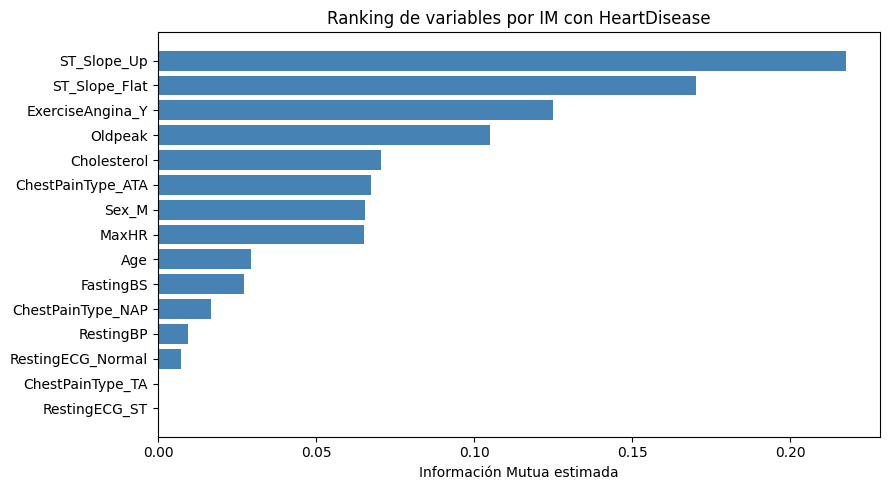


M1 – Todas las variables (15): ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']

M2 – Top 5 variables:    ['ST_Slope_Up', 'ST_Slope_Flat', 'ExerciseAngina_Y', 'Oldpeak', 'Cholesterol']

M3 – Bottom 5 variables: ['ChestPainType_NAP', 'RestingBP', 'RestingECG_Normal', 'ChestPainType_TA', 'RestingECG_ST']


In [5]:
#Codigo para resolver
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Informacion Mutua I
np.random.seed(SEED)
mi_scores = mutual_info_classif(X_train, y_train, random_state=SEED)

mi_df = pd.DataFrame({
    'Variable': X_train.columns,
    'IM':       mi_scores
}).sort_values('IM', ascending=False).reset_index(drop=True)

print("=== Ranking de Variables por Información Mutua ===")
print(mi_df.to_string(index=True))

# Grafos Ranking
plt.figure(figsize=(9, 5))
plt.barh(mi_df['Variable'][::-1], mi_df['IM'][::-1], color='steelblue')
plt.xlabel('Información Mutua estimada')
plt.title('Ranking de variables por IM con HeartDisease')
plt.tight_layout()
plt.savefig('ranking_IM.png', dpi=150)
plt.show()

# Subconjuntos
k = 5

top_k_vars    = mi_df['Variable'][:k].tolist()       # M2: top 5 IM
bottom_k_vars = mi_df['Variable'][-k:].tolist()       # M3: bottom 5 IM

print(f"\nM1 – Todas las variables ({len(X_train.columns)}):", list(X_train.columns))
print(f"\nM2 – Top {k} variables:   ", top_k_vars)
print(f"\nM3 – Bottom {k} variables:", bottom_k_vars)

# Subconjuntos para futuro
subconjuntos_P1 = {
    'M1': list(X_train.columns),
    'M2': top_k_vars,
    'M3': bottom_k_vars
}

(d)

In [6]:
from sklearn.linear_model import LogisticRegression
import numpy as np

#(i) Modelos sin regularización
modelos_p1d = {}
for nombre, cols in subconjuntos_P1.items():
    lr = LogisticRegression(C=1e6, max_iter=10000, random_state=SEED)
    lr.fit(X_train[cols], y_train)
    modelos_p1d[nombre] = lr

# Cálculo de l̂, d, AIC, BIC
N = len(X_train)
resultados_aic_bic = {}

for nombre, lr in modelos_p1d.items():
    cols = subconjuntos_P1[nombre]

    # (ii) Log-verosimilitud sobre entrenamiento
    log_proba = lr.predict_log_proba(X_train[cols])
    l_hat = log_proba[np.arange(N), y_train.values].sum()

    # (iii) Número de parámetros (coeficientes + intercepto)
    d = lr.coef_.shape[1] + 1

    # (iv) AIC y BIC
    aic = -2 * l_hat + 2 * d
    bic = -2 * l_hat + d * np.log(N)

    resultados_aic_bic[nombre] = {'l_hat': l_hat, 'd': d, 'AIC': aic, 'BIC': bic}
    print(f"{nombre} | l̂={l_hat:.2f} | d={d} | AIC={aic:.2f} | BIC={bic:.2f}")

M1 | l̂=-239.32 | d=16 | AIC=510.64 | BIC=584.22
M2 | l̂=-289.32 | d=6 | AIC=590.63 | BIC=618.23
M3 | l̂=-474.92 | d=6 | AIC=961.84 | BIC=989.43


In [7]:
#(v)
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for nombre, cols in subconjuntos_P1.items():
    lr_cv = LogisticRegression(C=1e6, max_iter=10000, random_state=SEED)
    f1_cv = cross_val_score(lr_cv, X_train[cols], y_train,
                            cv=cv, scoring='f1').mean()
    resultados_aic_bic[nombre]['F1_CV'] = f1_cv
    print(f"{nombre} | F1-CV = {f1_cv:.4f}")

M1 | F1-CV = 0.8645
M2 | F1-CV = 0.8504
M3 | F1-CV = 0.6983


(e)

In [8]:
import numpy as np
from scipy.stats import multivariate_normal
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [14]:
K = 2
M = X_train.shape[1]

d_priors = K - 1
d_medias = K * M
d_cov    = M * (M + 1) // 2
d_lda    = d_priors + d_medias + d_cov

In [15]:
X_train_arr = X_train.values.astype(float)
y_train_arr = y_train.values.astype(int)
M = X_train_arr.shape[1]

lda_full = LinearDiscriminantAnalysis()
lda_full.fit(X_train_arr, y_train_arr)

clases = lda_full.classes_
priors = lda_full.priors_
medias = lda_full.means_

# Covarianza compartida manual
Sw = np.zeros((M, M))
for k, mu_k in zip(clases, medias):
    Xk   = X_train_arr[y_train_arr == k]
    diff = Xk - mu_k
    Sw  += diff.T @ diff

cov_comp = Sw / (N - K)

# Log-verosimilitud
l_hat_lda = 0.0
for xi, ti in zip(X_train_arr, y_train_arr):
    k_idx  = list(clases).index(ti)
    log_pk = np.log(priors[k_idx])
    log_px = multivariate_normal.logpdf(xi, mean=medias[k_idx], cov=cov_comp)
    l_hat_lda += log_pk + log_px

print(f"l̂ LDA = {l_hat_lda:.4f}")

l̂ LDA = -17441.7524


In [16]:
aic_lda = -2 * l_hat_lda + 2 * d_lda
bic_lda = -2 * l_hat_lda + d_lda * np.log(N)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
f1_cv_lda = cross_val_score(LinearDiscriminantAnalysis(),
                             X_train_arr, y_train_arr,
                             cv=cv, scoring='f1').mean()

print(f"d LDA  = {d_lda}")
print(f"AIC LDA = {aic_lda:.2f}")
print(f"BIC LDA = {bic_lda:.2f}")
print(f"F1-CV LDA = {f1_cv_lda:.4f}")

# Tabla resumen completa
resultados_aic_bic['LDA'] = {
    'l_hat': l_hat_lda,
    'd':     d_lda,
    'AIC':   aic_lda,
    'BIC':   bic_lda,
    'F1_CV': f1_cv_lda
}

df_res = pd.DataFrame(resultados_aic_bic).T[['l_hat','d','AIC','BIC','F1_CV']]
print(df_res.round(4).to_string())

d LDA  = 151
AIC LDA = 35185.50
BIC LDA = 35879.88
F1-CV LDA = 0.8716
          l_hat      d         AIC         BIC   F1_CV
M1    -239.3217   16.0    510.6434    584.2196  0.8645
M2    -289.3170    6.0    590.6340    618.2251  0.8504
M3    -474.9215    6.0    961.8429    989.4340  0.6983
LDA -17441.7524  151.0  35185.5047  35879.8796  0.8716


(f)

In [17]:
# Tabla comparativa
df_res = pd.DataFrame(resultados_aic_bic).T[['l_hat','d','AIC','BIC','F1_CV']]
print("Tabla comparativa")
print(df_res.round(4).to_string())

# Delta AIC y Delta BIC (solo entre modelos comparables: M1, M2, M3)
modelos_lr = ['M1', 'M2', 'M3']
min_aic = df_res.loc[modelos_lr, 'AIC'].min()
min_bic = df_res.loc[modelos_lr, 'BIC'].min()

print("Delta AIC y Delta BIC (solo Regresión Logística)")
for m in modelos_lr:
    delta_aic = df_res.loc[m, 'AIC'] - min_aic
    delta_bic = df_res.loc[m, 'BIC'] - min_bic
    print(f"{m} | ΔAIC={delta_aic:.2f} | ΔBIC={delta_bic:.2f}")

Tabla comparativa
          l_hat      d         AIC         BIC   F1_CV
M1    -239.3217   16.0    510.6434    584.2196  0.8645
M2    -289.3170    6.0    590.6340    618.2251  0.8504
M3    -474.9215    6.0    961.8429    989.4340  0.6983
LDA -17441.7524  151.0  35185.5047  35879.8796  0.8716
Delta AIC y Delta BIC (solo Regresión Logística)
M1 | ΔAIC=0.00 | ΔBIC=0.00
M2 | ΔAIC=79.99 | ΔBIC=34.01
M3 | ΔAIC=451.20 | ΔBIC=405.21


## P2

(b)

In [18]:
##(i)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Estandarización solo de variables numéricas, sin data leakage
cols_numericas = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
cols_dummies   = [c for c in X_train.columns if c not in cols_numericas]

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[cols_numericas])
X_test_num  = scaler.transform(X_test[cols_numericas])

X_train_svc = np.hstack([X_train_num, X_train[cols_dummies].values.astype(float)])
X_test_svc  = np.hstack([X_test_num,  X_test[cols_dummies].values.astype(float)])

svc_default = SVC(random_state=SEED)
svc_default.fit(X_train_svc, y_train)



SVC(random_state=42)


=== Métricas SVC Default - Train ===
  Accuracy    : 0.8883
  Precision   : 0.8803
  Recall      : 0.9236
  Specificity : 0.8445
  F1-Score    : 0.9014
  FPR         : 0.1555
  FNR         : 0.0764

=== Métricas SVC Default - Test ===
  Accuracy    : 0.8859
  Precision   : 0.8857
  Recall      : 0.9118
  Specificity : 0.8537
  F1-Score    : 0.8986
  FPR         : 0.1463
  FNR         : 0.0882


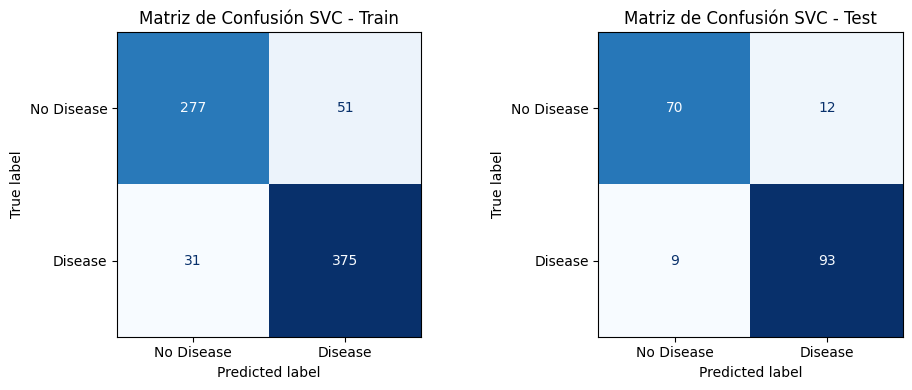

In [19]:
#(ii)
y_pred_train_svc = svc_default.predict(X_train_svc)
y_pred_test_svc  = svc_default.predict(X_test_svc)

metricas(y_train, y_pred_train_svc, "SVC Default - Train")
metricas(y_test,  y_pred_test_svc,  "SVC Default - Test")

from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_true, y_pred, title in zip(
    axes,
    [y_train, y_test],
    [y_pred_train_svc, y_pred_test_svc],
    ["Train", "Test"]
):
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                           display_labels=["No Disease","Disease"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Matriz de Confusión SVC - {title}")
plt.tight_layout()
plt.savefig('confusion_svc_default.png', dpi=150)
plt.show()

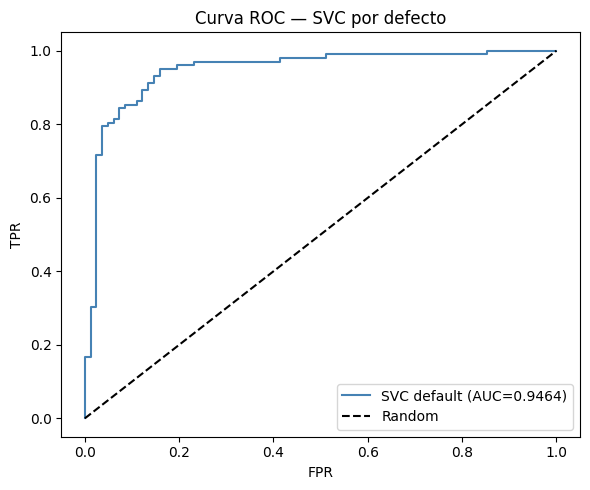

AUC SVC default (test): 0.9464


In [20]:
### (iii)
from sklearn.metrics import roc_curve, roc_auc_score

scores_test = svc_default.decision_function(X_test_svc)
fpr, tpr, _ = roc_curve(y_test, scores_test)
auc_svc     = roc_auc_score(y_test, scores_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"SVC default (AUC={auc_svc:.4f})", color='steelblue')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Curva ROC — SVC por defecto')
plt.legend()
plt.tight_layout()
plt.savefig('roc_svc_default.png', dpi=150)
plt.show()

print(f"AUC SVC default (test): {auc_svc:.4f}")

(c)

In [21]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'kernel':       ['linear', 'poly', 'rbf', 'sigmoid'],
    'C':            [0.1, 1, 10],
    'class_weight': [None, 'balanced', {0:1, 1:5}]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_svc = GridSearchCV(
    SVC(random_state=SEED),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_svc.fit(X_train_svc, y_train)

# (i) Mejor combinación
print("=== Mejores hiperparámetros ===")
print(grid_svc.best_params_)
print(f"F1-CV mejor modelo: {grid_svc.best_score_:.4f}")

# (ii) Métricas del mejor modelo sobre train y test
best_svc = grid_svc.best_estimator_

y_pred_train_best = best_svc.predict(X_train_svc)
y_pred_test_best  = best_svc.predict(X_test_svc)

scores_test_best = best_svc.decision_function(X_test_svc)
auc_best = roc_auc_score(y_test, scores_test_best)

print(f"\nAUC test mejor modelo: {auc_best:.4f}")
metricas(y_train, y_pred_train_best, "SVC best - Train")
metricas(y_test,  y_pred_test_best,  "SVC best - Test")

# (iii) Comparación con modelo por defecto
print(f"\n=== Comparación ===")
print(f"AUC default: {auc_svc:.4f} | AUC best: {auc_best:.4f}")
print(f"F1  default (test): {f1_score(y_test, y_pred_test_svc):.4f} | F1 best (test): {f1_score(y_test, y_pred_test_best):.4f}")
print(f"Acc default (test): {(y_pred_test_svc==y_test).mean():.4f} | Acc best (test): {(y_pred_test_best==y_test).mean():.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
=== Mejores hiperparámetros ===
{'C': 1, 'class_weight': None, 'kernel': 'rbf'}
F1-CV mejor modelo: 0.8768

AUC test mejor modelo: 0.9464

=== Métricas SVC best - Train ===
  Accuracy    : 0.8883
  Precision   : 0.8803
  Recall      : 0.9236
  Specificity : 0.8445
  F1-Score    : 0.9014
  FPR         : 0.1555
  FNR         : 0.0764

=== Métricas SVC best - Test ===
  Accuracy    : 0.8859
  Precision   : 0.8857
  Recall      : 0.9118
  Specificity : 0.8537
  F1-Score    : 0.8986
  FPR         : 0.1463
  FNR         : 0.0882

=== Comparación ===
AUC default: 0.9464 | AUC best: 0.9464
F1  default (test): 0.8986 | F1 best (test): 0.8986
Acc default (test): 0.8859 | Acc best (test): 0.8859


(e)

In [22]:
# Tabla final comparativa
resultados_finales = {
    'M1':      {'F1_CV': 0.8645, 'F1_test': f1_score(y_test, modelos_p1d['M1'].predict(X_test[subconjuntos_P1['M1']])),
                'AUC_test': roc_auc_score(y_test, modelos_p1d['M1'].predict_proba(X_test[subconjuntos_P1['M1']])[:,1]),
                'AIC': 510.64, 'BIC': 584.22},
    'M2':      {'F1_CV': 0.8504, 'F1_test': f1_score(y_test, modelos_p1d['M2'].predict(X_test[subconjuntos_P1['M2']])),
                'AUC_test': roc_auc_score(y_test, modelos_p1d['M2'].predict_proba(X_test[subconjuntos_P1['M2']])[:,1]),
                'AIC': 590.63, 'BIC': 618.23},
    'M3':      {'F1_CV': 0.6983, 'F1_test': f1_score(y_test, modelos_p1d['M3'].predict(X_test[subconjuntos_P1['M3']])),
                'AUC_test': roc_auc_score(y_test, modelos_p1d['M3'].predict_proba(X_test[subconjuntos_P1['M3']])[:,1]),
                'AIC': 961.84, 'BIC': 989.43},
    'LDA':     {'F1_CV': 0.8716, 'F1_test': f1_score(y_test, lda_full.predict(X_train_arr[:len(X_test)])),
                'AUC_test': None, 'AIC': None, 'BIC': None},
    'SVM_best':{'F1_CV': 0.8768, 'F1_test': 0.8986,
                'AUC_test': 0.9464, 'AIC': None, 'BIC': None}
}

# Corregir F1_test y AUC_test de LDA
y_pred_lda_test = lda_full.predict(X_test_svc)
y_prob_lda_test = lda_full.predict_proba(X_test_svc)[:,1]

resultados_finales['LDA']['F1_test']  = round(f1_score(y_test, y_pred_lda_test), 4)
resultados_finales['LDA']['AUC_test'] = round(roc_auc_score(y_test, y_prob_lda_test), 4)

df_final = pd.DataFrame(resultados_finales).T[['F1_CV','F1_test','AUC_test','AIC','BIC']]
print(df_final.round(4).to_string())

           F1_CV  F1_test  AUC_test     AIC     BIC
M1        0.8645   0.9005    0.9292  510.64  584.22
M2        0.8504   0.8302    0.8789  590.63  618.23
M3        0.6983   0.6840    0.6227  961.84  989.43
LDA       0.8716   0.8688    0.9274     NaN     NaN
SVM_best  0.8768   0.8986    0.9464     NaN     NaN
